In [1]:
from copy import deepcopy
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.burgers import (
    BurgersMultiTrajectoryGLSConfig,
    build_burgers_weak_validation_blocks,
    fit_burgers_multi_trajectory_coefficients,
    generate_burgers_dataset,
    get_burgers_feature_names,
    run_burgers_multi_trajectory_gls_experiment,
)
from mfsindy.cases.burgers_plots import COLORS_MODELS
from mfsindy.experiments import (
    evaluate_weak_form_models,
    format_coefficient_equations,
    make_metric_scorer,
    optimize_hyperparams,
    split_trajectory_list,
)
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("results")
if not RESULTS_DIR.exists():
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
elif not RESULTS_DIR.is_dir():
    raise NotADirectoryError(f"{RESULTS_DIR} exists and is not a directory")

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]
cfg = BurgersMultiTrajectoryGLSConfig(
    n_runs=5,
    T_train=0.1,
    dt = 0.001,
    nu = 0.1,
    K = 100,
    include_bias=True,
    results_dir=str(RESULTS_DIR),
    results_filename="burgers_part1_errors.csv",
)


# Burgers Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the Burgers equation using the multi-trajectory (Part 1) workflow.

## Governing equations

The one-dimensional viscous Burgers equation is

$$
\partial_t u + u\partial_x u = \nu\partial_{xx} u,
$$

where $u(x,t)$ is the state variable and $\nu$ is the viscosity coefficient.

We use viscosity $\nu$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.

### Trajectory snapshot
Preview noisy LF/HF trajectories and a clean reference.

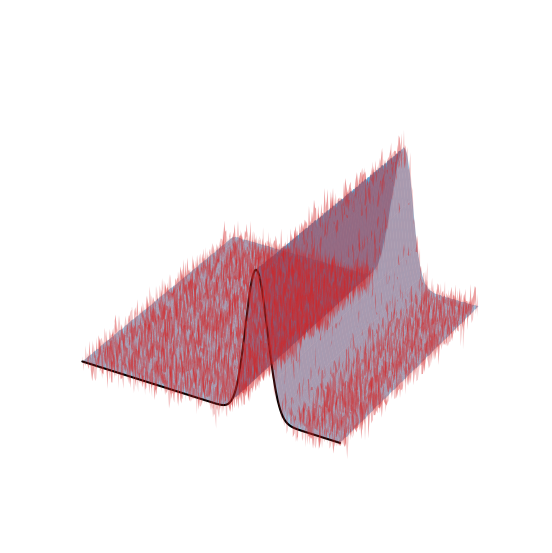

In [2]:
from mfsindy.cases.burgers_plots import plot_multifidelity_trajectories
X_ref, t_ref, x_ref,_ = generate_burgers_dataset(
    n_traj=1,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=0.0,
    seed=cfg.seed_base,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu
)

X_hf_noisy, _, _, _ = generate_burgers_dataset(
    n_traj=cfg.n_hf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=cfg.noise_hf_rel*np.std(X_ref),
    seed=cfg.seed_base,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu
)

X_lf_noisy, _, _, _ = generate_burgers_dataset(
    n_traj=cfg.n_lf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=cfg.noise_lf_rel*np.std(X_ref),
    seed=cfg.seed_base,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu
)
plot_multifidelity_trajectories(X_hf_noisy, X_lf_noisy, X_ref, x_ref, t_ref)


### Hyperparameter Selection

Use one HF/LF ensemble draw, split trajectories 80-20 into train and validation sets, tune the weak-form hyperparameters separately for each model by maximizing held-out weak-form $R^2$, then refit on the full ensemble and print the resulting equations.


In [ ]:
H_X_CANDIDATES = [cfg.L/20]
H_T_CANDIDATES = [cfg.T_train/20]

SEARCH_GRID = {
    "stlsq_threshold": [0.1],
    "H_xt": [[h_x, h_t] for h_x in H_X_CANDIDATES for h_t in H_T_CANDIDATES],
}

X_ref_search, t_search, x_search, _ = generate_burgers_dataset(
    n_traj=1,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=0.0,
    seed=cfg.seed_base,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu,
)
state_std = float(np.std(X_ref_search[0]))
noise_hf_abs = cfg.noise_hf_rel * state_std
noise_lf_abs = cfg.noise_lf_rel * state_std

X_hf_search, _, _, _ = generate_burgers_dataset(
    n_traj=cfg.n_hf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=noise_hf_abs,
    seed=cfg.seed_base,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu,
)
X_lf_search, _, _, _ = generate_burgers_dataset(
    n_traj=cfg.n_lf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=noise_lf_abs,
    seed=cfg.seed_base + 100,
    L=cfg.L,
    NX=cfg.NX,
    nu=cfg.nu,
)

hf_train, hf_val = split_trajectory_list(X_hf_search, validation_fraction=0.2)
lf_train, lf_val = split_trajectory_list(X_lf_search, validation_fraction=0.2)

search_results = {}
best_params_by_model = {}
tuned_cfg_by_model = {}
tuned_equations = {}

def evaluate_candidate(candidate_cfg):
    coef_map = fit_burgers_multi_trajectory_coefficients(
        candidate_cfg,
        hf_trajectories=hf_train,
        lf_trajectories=lf_train,
        t_grid=t_search,
        x_grid=x_search,
        noise_hf_abs=noise_hf_abs,
        noise_lf_abs=noise_lf_abs,
        weak_seed=candidate_cfg.seed_base + 40_000,
    )
    validation_blocks = (
        build_burgers_weak_validation_blocks(
            candidate_cfg,
            hf_val,
            t_grid=t_search,
            x_grid=x_search,
            weak_seed=candidate_cfg.seed_base + 40_010,
            group_name="HF validation",
        )
        + build_burgers_weak_validation_blocks(
            candidate_cfg,
            lf_val,
            t_grid=t_search,
            x_grid=x_search,
            weak_seed=candidate_cfg.seed_base + 40_020,
            group_name="LF validation",
        )
    )
    return evaluate_weak_form_models(coef_map, validation_blocks)

for target_model in MODELS:
    search = optimize_hyperparams(
        cfg,
        param_grid=SEARCH_GRID,
        evaluate=evaluate_candidate,
        score_fn=make_metric_scorer(source=target_model, metric="weak_r2"),
        maximize=True,
    )
    tuned_cfg = deepcopy(search.best_config)
    search_results[target_model] = search
    best_params_by_model[target_model] = search.best_params
    tuned_cfg_by_model[target_model] = tuned_cfg
    full_coef_map = fit_burgers_multi_trajectory_coefficients(
        tuned_cfg,
        hf_trajectories=X_hf_search,
        lf_trajectories=X_lf_search,
        t_grid=t_search,
        x_grid=x_search,
        noise_hf_abs=noise_hf_abs,
        noise_lf_abs=noise_lf_abs,
        weak_seed=tuned_cfg.seed_base + 40_001,
    )
    tuned_equations[target_model] = full_coef_map[target_model]

feature_names = get_burgers_feature_names(
    cfg,
    t_grid=t_search,
    x_grid=x_search,
    reference_trajectory=X_hf_search[0],
)
print(pd.DataFrame(best_params_by_model).T)
print(
    format_coefficient_equations(
        tuned_equations,
        feature_names=feature_names,
        state_names=("u_t",),
        precision=3,
    )
)


0it [00:00, ?it/s]

### Run

In [ ]:
df_errors_parts = []
for model_name in MODELS:
    method_cfg = deepcopy(tuned_cfg_by_model[model_name])
    method_cfg.results_dir = str(RESULTS_DIR)
    method_cfg.results_filename = f"burgers_part1_{model_name.lower()}_errors.csv"
    df_model, _, _, _, _, _ = run_burgers_multi_trajectory_gls_experiment(method_cfg)
    df_errors_parts.append(df_model[df_model["model"] == model_name].copy())

df_errors = pd.concat(df_errors_parts, ignore_index=True)
df_errors.to_csv(Path(cfg.results_dir) / cfg.results_filename, index=False)

def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)

print("Mean Absolute Error")
print(mae_summary)
print("Support Fraction Error")
print(l0_summary)


Monte Carlo Burgers MF:   0%|          | 0/5 [00:00<?, ?it/s]

Monte Carlo Burgers MF:   0%|          | 0/5 [00:28<?, ?it/s]


ValueError: Shape mismatch in coefficient_errors: C_est (1, 5), C_true (1, 6)

### Error summaries
Bubble histograms summarise the MAE and $L_0$ distributions across methods.

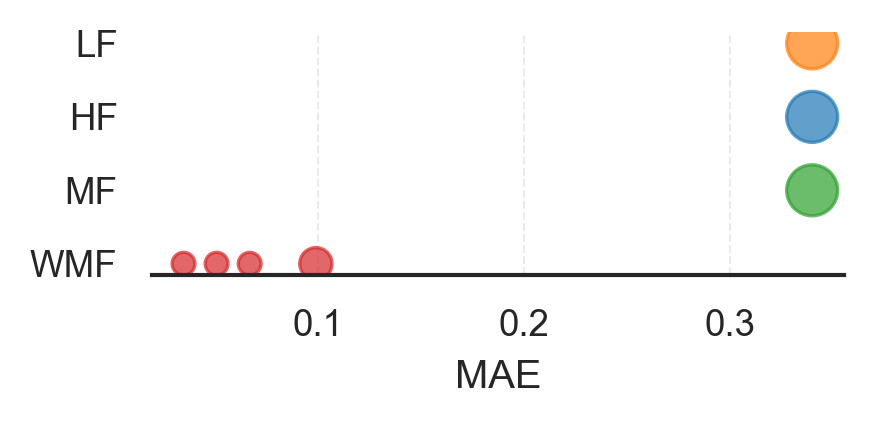

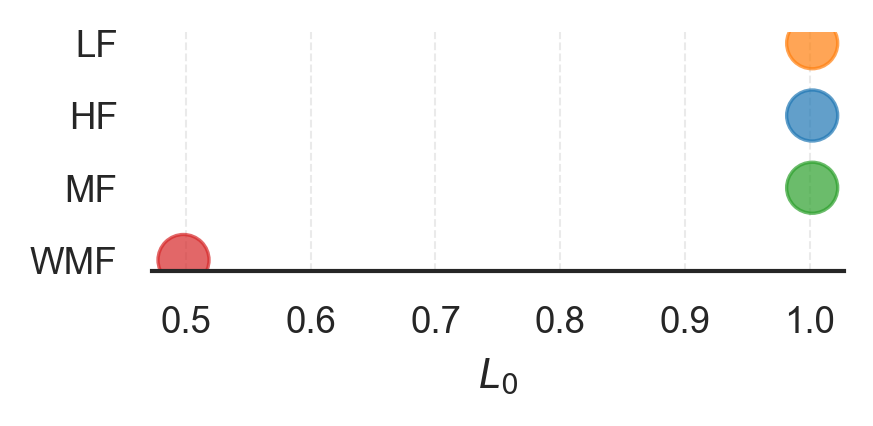

In [ ]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
labels = ["WMF", "MF", "HF", "LF"]

bubble_hist(
    errors_dict=mae_errors,
    xlabel="MAE",
    n_bins=20,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

bubble_hist(
    errors_dict=l0_errors,
    xlabel=r"$L_0$",
    n_bins=12,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

